<a href="https://colab.research.google.com/github/darshanmodi-cmyk/Virtual-Data-Science-with-Python-Trainee/blob/main/Task1_data_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Set aesthetic style for figures
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Ingest dataset
# If running in Colab with file uploaded:
df = pd.read_csv("Churn_Modelling.csv")

print(f"Dataset successfully loaded. Dimensions: {df.shape}")
df.head()

Dataset successfully loaded. Dimensions: (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
# 1. Structural summary and data types
print("Dataset Information")
df.info()

# 2. Check for missing values
print("\n Missing Values Per Column ")
print(df.isnull().sum())

# 3. Check for duplicated rows
print(f"\nDuplicate rows detected: {df.duplicated().sum()}")

# 4. Statistical summary of numerical columns
df.describe().T

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB

 Missing Values Per Column 
RowNumber          0
CustomerId         0
Sur

,count,mean,std,min,25%,50%,75%,max
RowNumber,10000.0,5.000500e+03,2886.895680,1.00,2500.75,5.000500e+03,7.500250e+03,10000.00
CustomerId,10000.0,1.569094e+07,71936.186123,15565701.00,15628528.25,1.569074e+07,1.575323e+07,15815690.00
CreditScore,10000.0,6.505288e+02,96.653299,350.00,584.00,6.520000e+02,7.180000e+02,850.00
Age,10000.0,3.892180e+01,10.487806,18.00,32.00,3.700000e+01,4.400000e+01,92.00
Tenure,10000.0,5.012800e+00,2.892174,0.00,3.00,5.000000e+00,7.000000e+00,10.00
Balance,10000.0,7.648589e+04,62397.405202,0.00,0.00,9.719854e+04,1.276442e+05,250898.09
NumOfProducts,10000.0,1.530200e+00,0.581654,1.00,1.00,1.000000e+00,2.000000e+00,4.00
HasCrCard,10000.0,7.055000e-01,0.455840,0.00,0.00,1.000000e+00,1.000000e+00,1.00
IsActiveMember,10000.0,5.151000e-01,0.499797,0.00,0.00,1.000000e+00,1.000000e+00,1.00
EstimatedSalary,10000.0,1.000902e+05,57510.492818,11.58,51002.11,1.001939e+05,1.493882e+05,199992.48


In [ ]:
# 1. Drop irrelevant identifier columns that do not contribute to modeling
cols_to_drop = ["RowNumber", "CustomerId", "Surname"]
df_clean = df.drop(
    columns=[c for c in cols_to_drop if c in df.columns], errors="ignore"
)

# 2. Drop duplicates if any exist
df_clean = df_clean.drop_duplicates()

# 3. Handle potential missing numerical entries via median imputation
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
for col in numeric_cols:
    if df_clean[col].isnull().sum() > 0:
        median_val = df_clean[col].median()
        df_clean[col] = df_clean[col].fillna(median_val)
        print(f"Imputed missing values in '{col}' with median: {median_val}")

print(f"Cleaned dataset dimensions: {df_clean.shape}")

Cleaned dataset dimensions: (10000, 11)


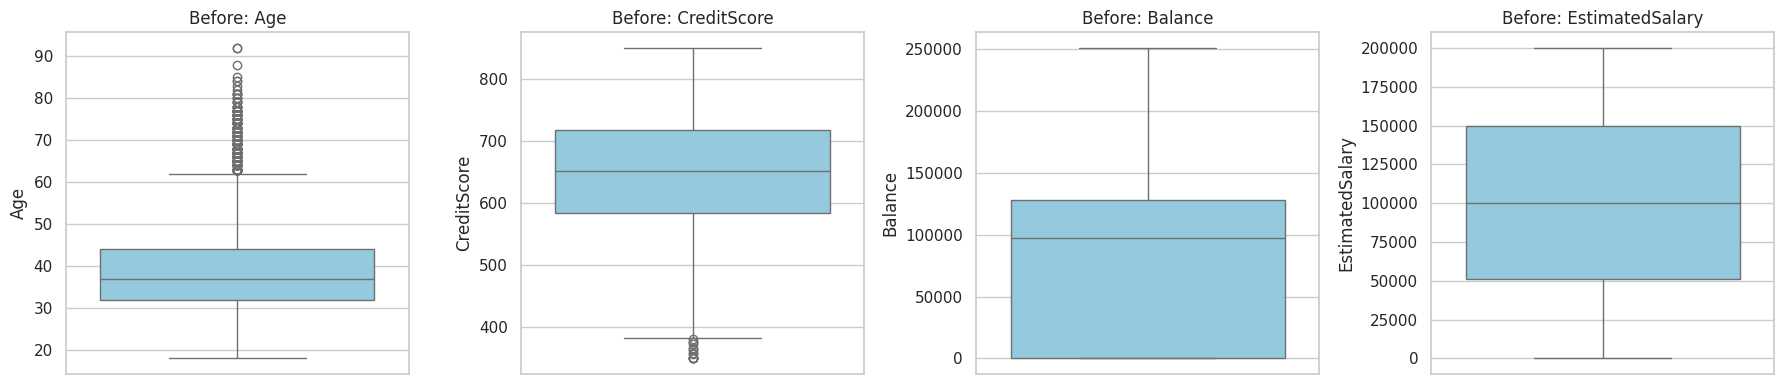

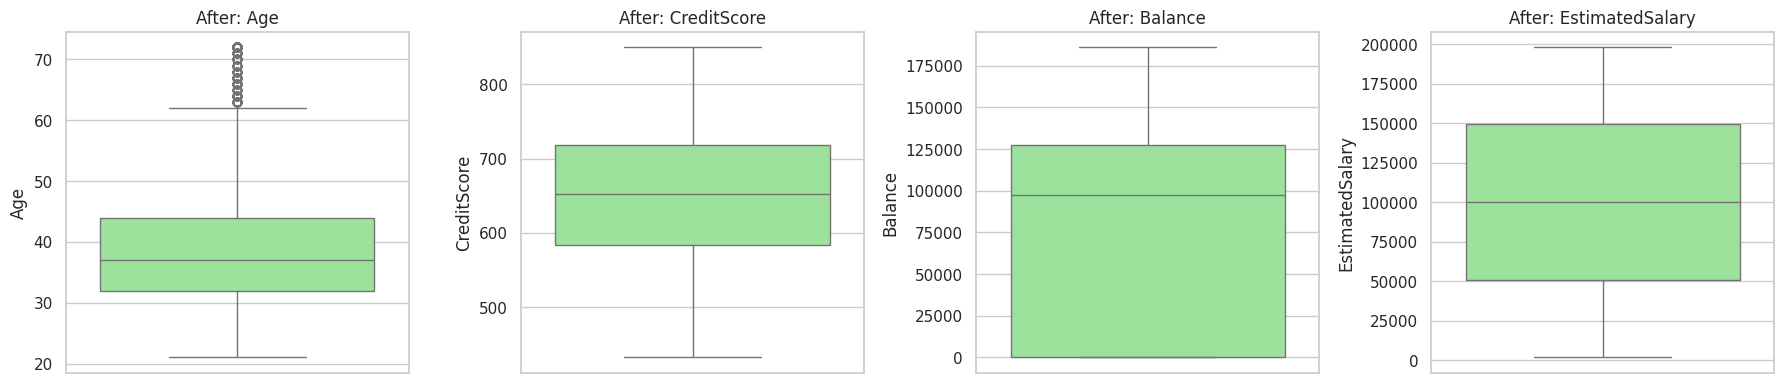

In [ ]:
# Define continuous columns for outlier inspection
continuous_features = ["Age", "CreditScore", "Balance", "EstimatedSalary"]

# Plot Boxplots BEFORE Winsorization
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for i, col in enumerate(continuous_features):
    sns.boxplot(y=df_clean[col], ax=axes[i], color="skyblue")
    axes[i].set_title(f"Before: {col}")
plt.tight_layout()
plt.savefig("outliers_before.png", dpi=300)
plt.show()


# Capping function
def winsorize_series(series, lower_q=0.01, upper_q=0.99):
    lower_bound = series.quantile(lower_q)
    upper_bound = series.quantile(upper_q)
    return series.clip(lower=lower_bound, upper=upper_bound)


for col in continuous_features:
    df_clean[col] = winsorize_series(df_clean[col])

# Plot Boxplots AFTER Winsorization
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for i, col in enumerate(continuous_features):
    sns.boxplot(y=df_clean[col], ax=axes[i], color="lightgreen")
    axes[i].set_title(f"After: {col}")
plt.tight_layout()
plt.savefig("outliers_after.png", dpi=300)
plt.show()

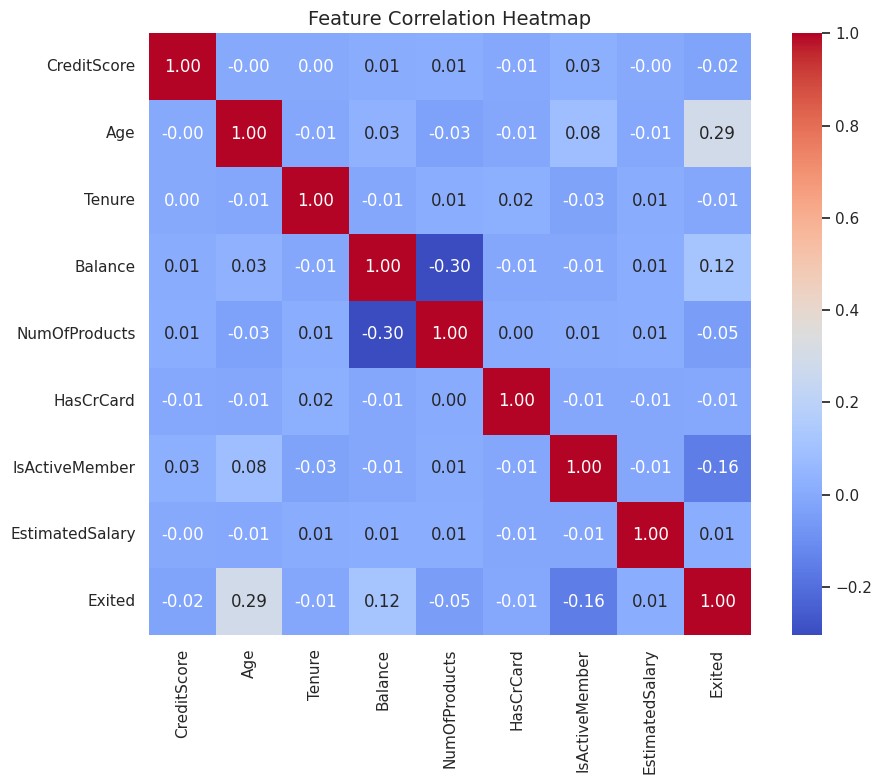

In [ ]:
# Correlation matrix of numerical variables
plt.figure(figsize=(10, 8))
corr_matrix = df_clean.select_dtypes(include=[np.number]).corr()
sns.heatmap(
    corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True, square=True
)
plt.title("Feature Correlation Heatmap", fontsize=14)
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=300)
plt.show()

In [ ]:
# 1. Separate features (X) and target (y)
X = df_clean.drop(columns=["Exited"])
y = df_clean["Exited"]

# 2. Stratified train-test split FIRST to prevent data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 3. Categorical vs numerical column separation
cat_features = ["Geography", "Gender"]
num_features = [col for col in X_train.columns if col not in cat_features]

# 4. Construct Preprocessor Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_features),
    ],
    remainder="passthrough",
)

# 5. Fit ONLY on X_train, then transform both X_train and X_test
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"Processed Training Shape: {X_train_processed.shape}")
print(f"Processed Testing Shape:  {X_test_processed.shape}")

Processed Training Shape: (8000, 11)
Processed Testing Shape:  (2000, 11)
